<a href="https://colab.research.google.com/github/subhamrungta-debug/volatility-model-nifty/blob/main/volatility_clustering_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- Code from main.ipynb starts here ---
# Import necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Data Acquisition and Pre-processing

In [ ]:
# Define the ticker symbol for NIFTY 50 and the date range
ticker = '^NSEI'
start_date = '2010-01-01'
end_date = '2023-12-31' # Using a fixed end date for reproducibility

# Download the data using yfinance
nifty_data = yf.download(ticker, start=start_date, end=end_date)

# Check columns in the downloaded data
print("Columns in downloaded data:", nifty_data.columns)

df = nifty_data[['Close']].copy()
price_col = 'Close'

# Calculate daily log returns
df['log_return'] = np.log(df[price_col] / df[price_col].shift(1))

# Drop the first row with NaN value
df.dropna(inplace=True)

# Display the first few rows of the processed data
print("NIFTY 50 Data with Log Returns:")
print(df.head())

/tmp/ipykernel_8206/369486001.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Columns in downloaded data: MultiIndex([( 'Close', '^NSEI'),
            (  'High', '^NSEI'),
            (   'Low', '^NSEI'),
            (  'Open', '^NSEI'),
            ('Volume', '^NSEI')],
           names=['Price', 'Ticker'])
NIFTY 50 Data with Log Returns:
Price             Close log_return
Ticker            ^NSEI           
Date                              
2010-01-05  5277.899902   0.008696
2010-01-06  5281.799805   0.000739
2010-01-07  5263.100098  -0.003547
2010-01-08  5244.750000  -0.003493
2010-01-11  5249.399902   0.000886


## 2. Exploratory Data Analysis (EDA)

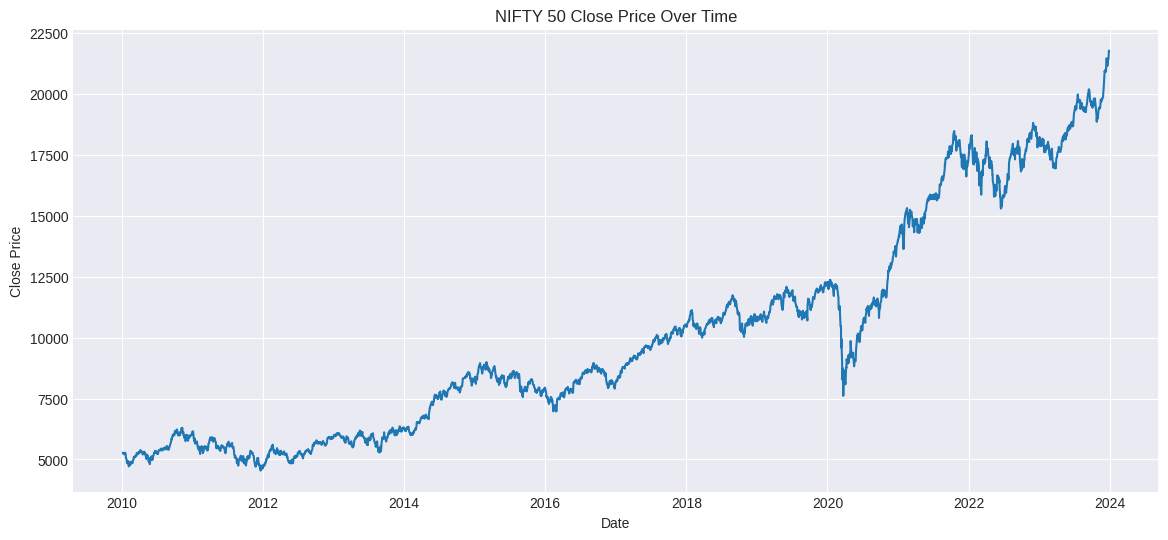

In [ ]:
# Plot the NIFTY 50 Close prices
plt.figure(figsize=(14, 6))
plt.plot(df.index, df[price_col])
plt.title('NIFTY 50 Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

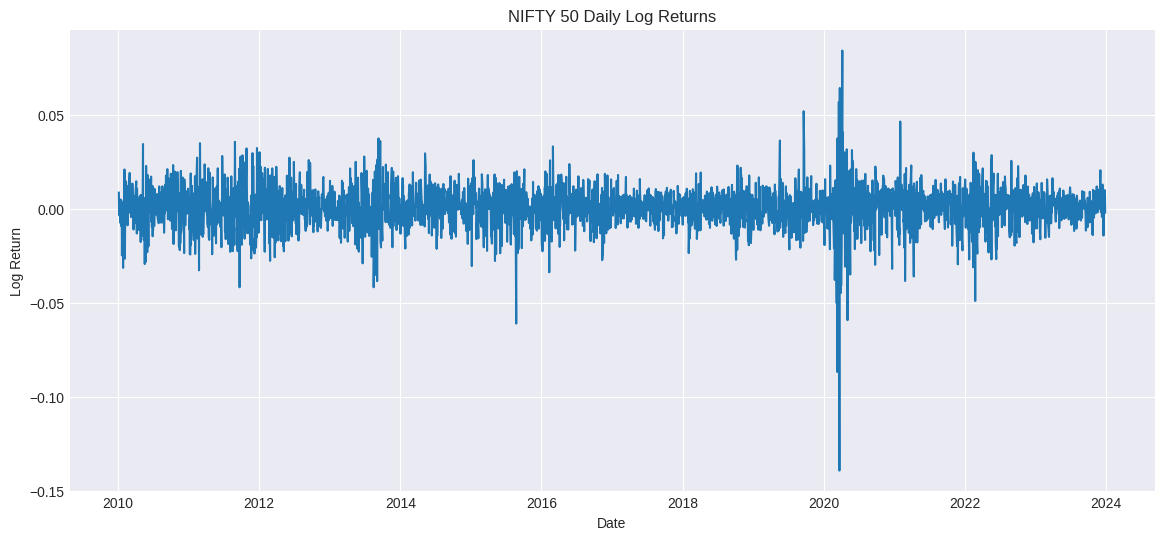

In [ ]:
# Plot the log returns
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['log_return'])
plt.title('NIFTY 50 Daily Log Returns')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.grid(True)
plt.show()

In [ ]:
# Descriptive statistics of log returns
print("Descriptive Statistics of Log Returns:")
print(df['log_return'].describe())

Descriptive Statistics of Log Returns:
count    3433.000000
mean        0.000415
std         0.010724
min        -0.139038
25%        -0.004954
50%         0.000665
75%         0.006230
max         0.084003
Name: log_return, dtype: float64


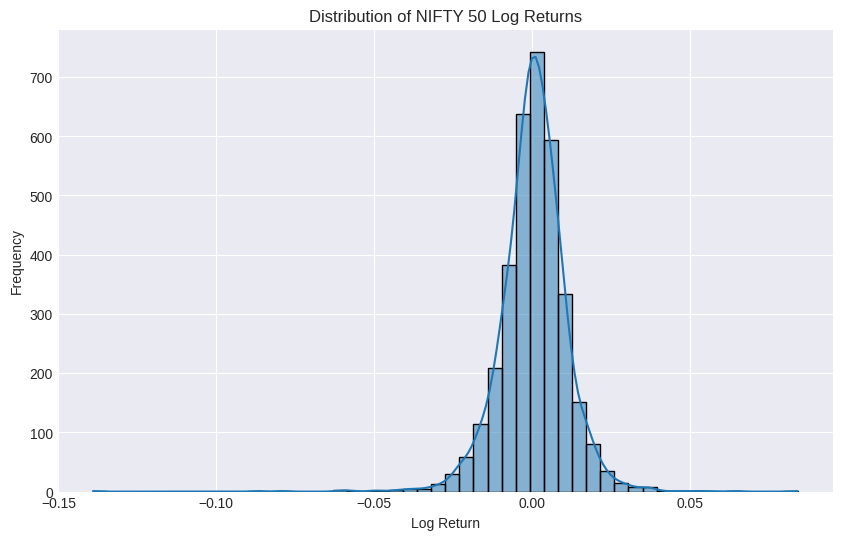

In [ ]:
# Distribution of log returns
plt.figure(figsize=(10, 6))
sns.histplot(df['log_return'], kde=True, bins=50)
plt.title('Distribution of NIFTY 50 Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.show()

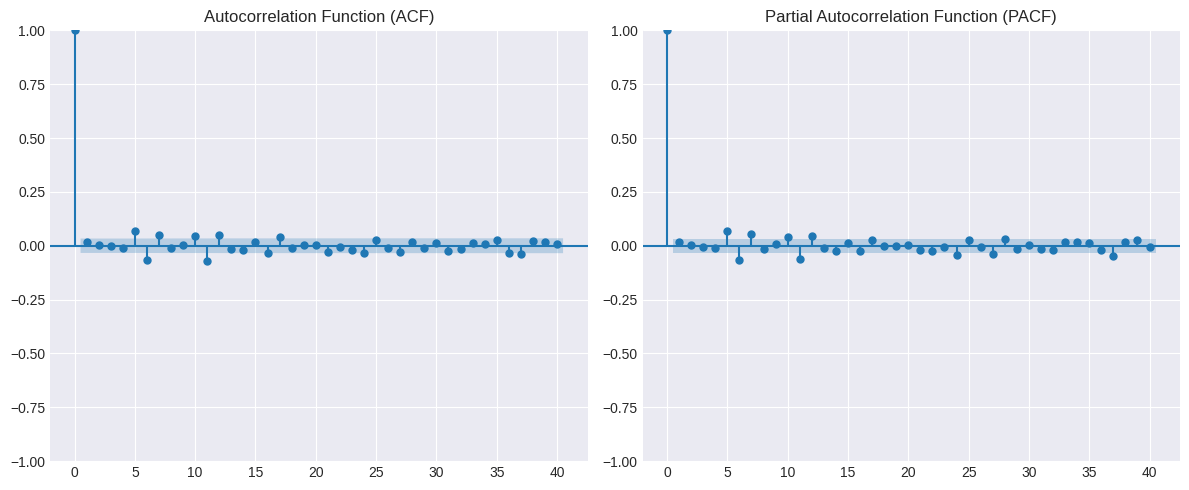

In [ ]:
# Autocorrelation and Partial Autocorrelation plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(df['log_return'], lags=40, ax=axes[0])
plot_pacf(df['log_return'], lags=40, ax=axes[1])
axes[0].set_title('Autocorrelation Function (ACF)')
axes[1].set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

## 3. Stationarity Test (ADF Test)

In [ ]:
# Perform Augmented Dickey-Fuller test
adf_test = adfuller(df['log_return'])
print('ADF Statistic: %f' % adf_test[0])
print('p-value: %f' % adf_test[1])
print('Critical Values:')
for key, value in adf_test[4].items():
    print('\t%s: %.3f' % (key, value))

if adf_test[1] < 0.05:
    print("\nResult: The series is stationary (reject H0).")
else:
    print("\nResult: The series is not stationary (fail to reject H0).")

ADF Statistic: -16.244327
p-value: 0.000000
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567

Result: The series is stationary (reject H0).


## 4. ARCH Effects Test

In [ ]:
# Perform ARCH-LM test
# The het_arch function from statsmodels performs the ARCH Lagrange Multiplier test.
# It takes the residuals (or in this case, the log returns) as input.
# The 'maxlag' parameter determines the number of lags to include in the test.
# A common choice for maxlag is often based on the ACF plot or domain knowledge.
# Here, we use 10 lags as a reasonable starting point.

arch_test_results = het_arch(df['log_return'], nlags=10)

# The output is a tuple containing (lm_statistic, p_value, f_statistic, f_p_value)
lm_statistic, p_value, f_statistic, f_p_value = arch_test_results

print(f"ARCH-LM Test Statistic: {lm_statistic}")
print(f"p-value: {p_value}")

if p_value < 0.05:
    print("\nResult: ARCH effects are present (reject H0 of no ARCH effects).")
else:
    print("\nResult: No ARCH effects detected (fail to reject H0).")

ARCH-LM Test Statistic: 861.4379170281094
p-value: 1.263980375573342e-178

Result: ARCH effects are present (reject H0 of no ARCH effects).


## 5. GARCH Model Fitting and Forecasting

In [ ]:
# Fit a GARCH(1,1) model
# We model the mean (mu) as a constant and the variance (omega) with GARCH(1,1).
# The distribution is set to 'StudentsT' to account for fat tails often observed in financial returns.
# The 'rescale' parameter is set to True to automatically scale the data, which can help with optimization.

model = arch_model(df['log_return'], mean='Constant', vol='GARCH', p=1, q=1, dist='StudentsT', rescale=True)
garch_result = model.fit(update_freq=5)

# Print model summary
print(garch_result.summary())

Iteration:      5,   Func. Count:     40,   Neg. LLF: 5532.837507583199
Iteration:     10,   Func. Count:     75,   Neg. LLF: 4603.913494331575
Optimization terminated successfully    (Exit mode 0)
            Current function value: 4603.913461808709
            Iterations: 13
            Function evaluations: 92
            Gradient evaluations: 13
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -4603.91
Distribution:      Standardized Student's t   AIC:                           9217.83
Method:                  Maximum Likelihood   BIC:                           9248.53
                                              No. Observations:                 3433
Date:                      Fri, Jun 12 2026   Df Res

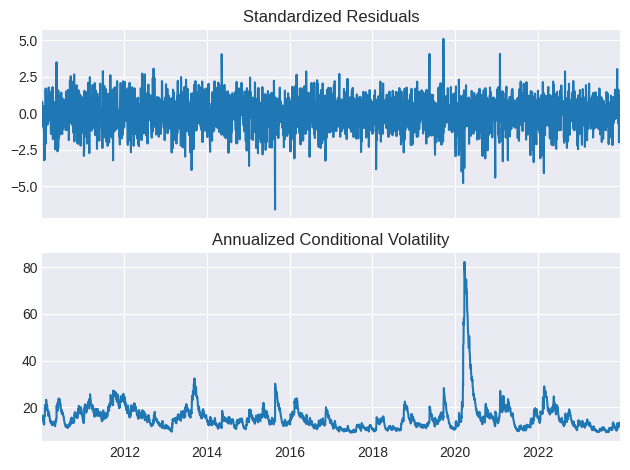

In [ ]:
# Plot standardized residuals and conditional volatility
fig = garch_result.plot(annualize='D')
plt.tight_layout()
plt.show()

In [ ]:
# Forecast future volatility (e.g., next 30 days)
forecasts = garch_result.forecast(horizon=30, reindex=False)
annualized_volatility = np.sqrt(forecasts.variance.iloc[-1] * 252)

print("\n30-Day Annualized Volatility Forecast:")
print(annualized_volatility)
# --- Code from main.ipynb ends here ---


30-Day Annualized Volatility Forecast:
h.01    12.083224
h.02    12.166850
h.03    12.248550
h.04    12.328383
h.05    12.406408
h.06    12.482679
h.07    12.557249
h.08    12.630168
h.09    12.701484
h.10    12.771244
h.11    12.839492
h.12    12.906269
h.13    12.971618
h.14    13.035577
h.15    13.098183
h.16    13.159474
h.17    13.219483
h.18    13.278246
h.19    13.335793
h.20    13.392156
h.21    13.447366
h.22    13.501451
h.23    13.554440
h.24    13.606359
h.25    13.657236
h.26    13.707096
h.27    13.755962
h.28    13.803859
h.29    13.850810
h.30    13.896838
Name: 2023-12-29 00:00:00, dtype: float64
